# 🌱 Smart Crop Recommendation Using Machine Learning-Based Soil and Climate Parameter Analysis
**Walchand College of Engineering, Sangli · Department of AIML · Mini Project (AY 2026-27)**

> *"How can we use soil and environmental parameters to recommend a suitable crop using a data-driven machine learning approach?"*

| Section | Group | Work |
|---|---|---|
| 01 | Group 1 – Data Foundation | Dataset overview, integrity checks, EDA, outlier treatment, preprocessing & handoff |
| 02 | Group 2 – Model & Prototype | 80/20 split, train 4 classifiers, compare, select best, save model |
| 03 | Group 3 – Evaluation & Testing | Metrics, 5-fold CV, confusion matrix, error analysis, prototype testing |

Run all cells top to bottom (**Runtime → Run all**).

## Setup

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

RANDOM_STATE = 42
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

---
# Section 01 — Data Collection, Preparation, EDA & Insights *(Group 1)*
## 1.1 Dataset selection & overview
**Selected:** Crop Recommendation Dataset (Kaggle, CSV, open source) — https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset

The cell below uses `Crop_recommendation.csv` if it is already in the Colab folder. Otherwise it downloads the file from Kaggle, and if that fails it asks you to upload it.

In [2]:
CSV_NAME = "Crop_recommendation.csv"

def load_dataset():
    if os.path.exists(CSV_NAME):
        print("Using local file:", CSV_NAME)
        return pd.read_csv(CSV_NAME)
    try:
        import kagglehub
        path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
        csv = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)[0]
        print("Downloaded from Kaggle:", csv)
        return pd.read_csv(csv)
    except Exception as e:
        print("Kaggle download failed:", e)
    from google.colab import files
    print("Please upload Crop_recommendation.csv")
    uploaded = files.upload()
    return pd.read_csv(list(uploaded.keys())[0])

df = load_dataset()
df.columns = [c.strip() for c in df.columns]
df.head()

  0%|          | 0.00/63.7k [00:00<?, ?B/s]

100%|██████████| 63.7k/63.7k [00:00<00:00, 228kB/s]

100%|██████████| 63.7k/63.7k [00:00<00:00, 226kB/s]

Extracting files...


Downloaded from Kaggle: C:\Users\Sameer\.cache\kagglehub\datasets\atharvaingle\crop-recommendation-dataset\versions\1\Crop_recommendation.csv


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print(f"Records        : {df.shape[0]}")
print(f"Input features : {len(FEATURES)}")
print(f"Crop classes   : {df[TARGET].nunique()}")
print(f"Samples / crop : {df[TARGET].value_counts().iloc[0]}")

units = {"N": "mg/kg", "P": "mg/kg", "K": "mg/kg", "temperature": "°C",
         "humidity": "%", "ph": "–", "rainfall": "mm"}
desc  = {"N": "Nitrogen in soil", "P": "Phosphorus in soil", "K": "Potassium in soil",
         "temperature": "Average temperature", "humidity": "Relative humidity",
         "ph": "Soil pH value", "rainfall": "Rainfall"}
overview = pd.DataFrame({
    "Description": [desc[f] for f in FEATURES],
    "Unit": [units[f] for f in FEATURES],
    "Range": [f"{df[f].min():.2f} – {df[f].max():.2f}" for f in FEATURES],
}, index=FEATURES)
overview

Records        : 2200
Input features : 7
Crop classes   : 22
Samples / crop : 100


,Description,Unit,Range
N,Nitrogen in soil,mg/kg,0.00 – 140.00
P,Phosphorus in soil,mg/kg,5.00 – 145.00
K,Potassium in soil,mg/kg,5.00 – 205.00
temperature,Average temperature,°C,8.83 – 43.68
humidity,Relative humidity,%,14.26 – 99.98
ph,Soil pH value,–,3.50 – 9.94
rainfall,Rainfall,mm,20.21 – 298.56


## 1.2 Data integrity & class balance

In [4]:
print("Missing values :", int(df.isnull().sum().sum()), "   (isnull().sum())")
print("Duplicate rows :", int(df.duplicated().sum()), "   (duplicated().sum())")
print("\nData types:")
print(df.dtypes)

Missing values : 0    (isnull().sum())
Duplicate rows : 0    (duplicated().sum())

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object


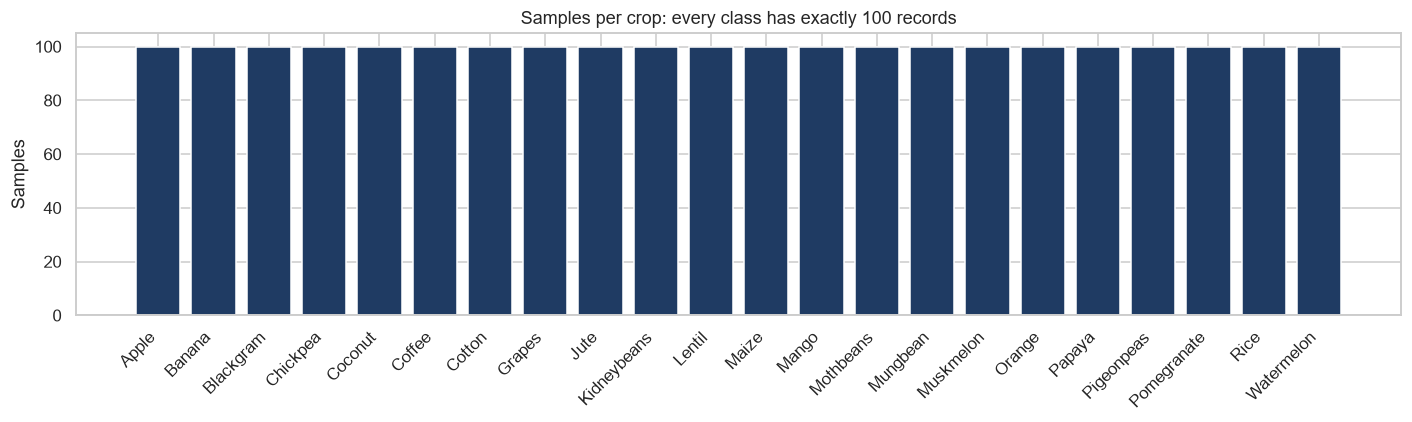

Balanced classes → accuracy is a fair metric and no resampling is needed.


In [5]:
counts = df[TARGET].value_counts().sort_index()
plt.figure(figsize=(13, 4))
plt.bar(counts.index.str.capitalize(), counts.values, color="#1f3b63")
plt.title(f"Samples per crop: every class has exactly {counts.max()} records")
plt.xticks(rotation=45, ha="right"); plt.ylabel("Samples")
plt.tight_layout(); plt.show()
print("Balanced classes → accuracy is a fair metric and no resampling is needed.")

## 1.3 EDA — feature spread & outlier analysis (1.5 × IQR rule)

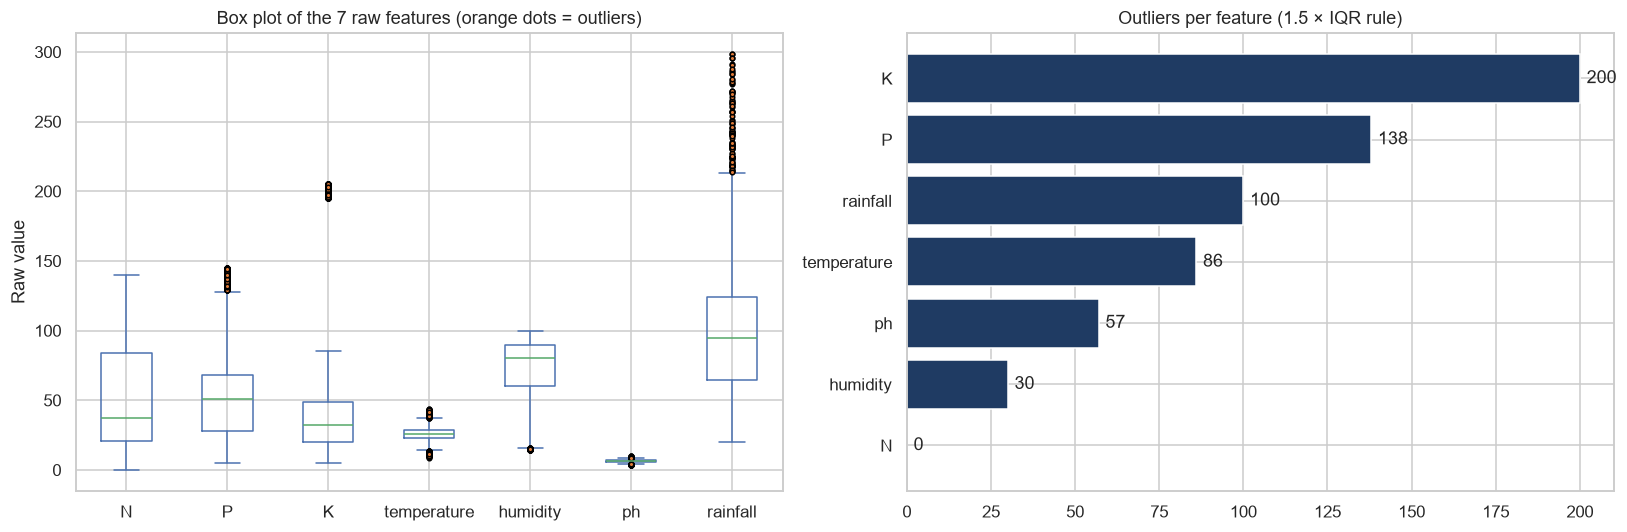

Total flagged values: 611


In [6]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_counts = {}
for f in FEATURES:
    lo, hi = iqr_bounds(df[f])
    outlier_counts[f] = int(((df[f] < lo) | (df[f] > hi)).sum())
outlier_counts = pd.Series(outlier_counts).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df[FEATURES].plot(kind="box", ax=axes[0], flierprops=dict(markerfacecolor="#e07b39", marker="o", markersize=3))
axes[0].set_title("Box plot of the 7 raw features (orange dots = outliers)"); axes[0].set_ylabel("Raw value")
axes[1].barh(outlier_counts.index, outlier_counts.values, color="#1f3b63")
for i, v in enumerate(outlier_counts.values):
    axes[1].text(v + 2, i, str(v), va="center")
axes[1].set_title("Outliers per feature (1.5 × IQR rule)")
plt.tight_layout(); plt.show()
print("Total flagged values:", outlier_counts.sum())

### Treatment: IQR capping
Values outside [Q1 − 1.5·IQR, Q3 + 1.5·IQR] are clipped to the boundary. No rows are dropped.

In [7]:
df_clean = df.copy()
CAP_BOUNDS = {}
flagged = 0
for f in FEATURES:
    lo, hi = iqr_bounds(df_clean[f])
    CAP_BOUNDS[f] = (lo, hi)
    flagged += int(((df_clean[f] < lo) | (df_clean[f] > hi)).sum())
    df_clean[f] = df_clean[f].clip(lo, hi)

remaining = sum(int(((df_clean[f] < CAP_BOUNDS[f][0]) | (df_clean[f] > CAP_BOUNDS[f][1])).sum()) for f in FEATURES)
print(f"{flagged} flagged values capped • {len(df) - len(df_clean)} rows dropped • {remaining} outliers remaining after capping")

611 flagged values capped • 0 rows dropped • 0 outliers remaining after capping


## 1.4 Correlation & key insights

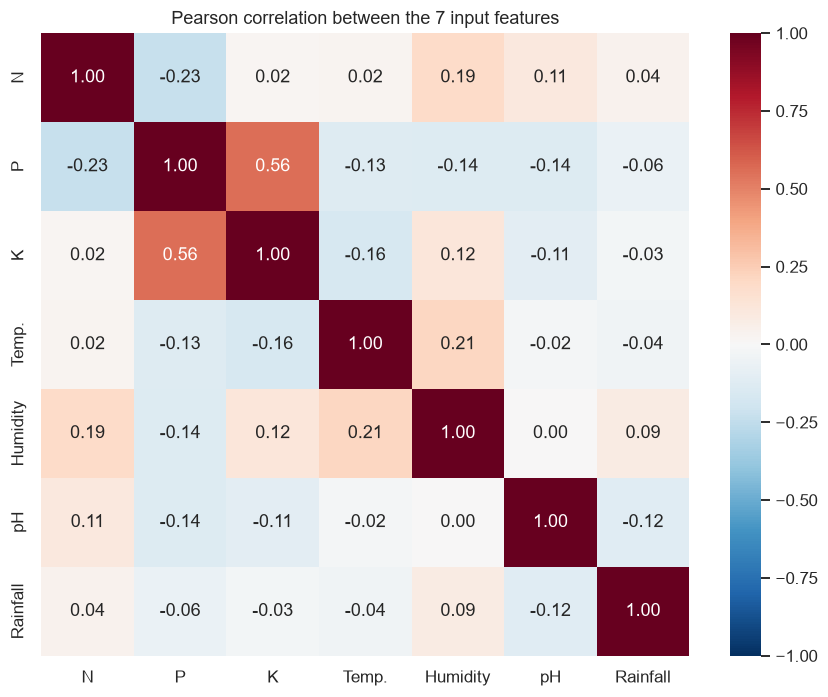

Strongest relationship : P & K  r = 0.56
All other pairs lie between -0.23 and 0.21 → all 7 features are kept
Very different scales  : rainfall 20–299 mm vs pH 3.5–9.9 → standard scaling required


In [8]:
corr = df_clean[FEATURES].corr()
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=["N", "P", "K", "Temp.", "Humidity", "pH", "Rainfall"],
            yticklabels=["N", "P", "K", "Temp.", "Humidity", "pH", "Rainfall"])
plt.title("Pearson correlation between the 7 input features")
plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
strongest = pairs.abs().idxmax()
others = pairs.drop(strongest)
print(f"Strongest relationship : {strongest[0]} & {strongest[1]}  r = {pairs[strongest]:.2f}")
print(f"All other pairs lie between {others.min():.2f} and {others.max():.2f} → all 7 features are kept")
print(f"Very different scales  : rainfall {df.rainfall.min():.0f}–{df.rainfall.max():.0f} mm vs pH {df.ph.min():.1f}–{df.ph.max():.1f} → standard scaling required")

## 1.5 Preprocessing pipeline & handoff
**Raw data → Integrity checks → Outlier capping → Label encoding → Standard scaling → `crop_recommendation_preprocessed.csv`**

In [9]:
label_encoder = LabelEncoder()
df_clean["label_encoded"] = label_encoder.fit_transform(df_clean[TARGET])
print("Label encoding:", {c: i for i, c in enumerate(label_encoder.classes_)})

scaler = StandardScaler()
scaled = scaler.fit_transform(df_clean[FEATURES])

df_pre = pd.DataFrame(scaled, columns=FEATURES)
df_pre[TARGET] = df_clean["label_encoded"].values
df_pre.to_csv("crop_recommendation_preprocessed.csv", index=False)

print(f"\nHandoff → crop_recommendation_preprocessed.csv • {df_pre.shape[0]} rows × {df_pre.shape[1]} columns • clean, encoded, scaled")
df_pre.describe().loc[["mean", "std"]].round(3)

Label encoding: {'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}

Handoff → crop_recommendation_preprocessed.csv • 2200 rows × 8 columns • clean, encoded, scaled


,N,P,K,temperature,humidity,ph,rainfall,label
mean,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,10.500
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.346


---
# Section 02 — Model Building, Best Model Selection & Prototype *(Group 2)*
## 2.1 Modelling workflow
Preprocessed data → Train/test split → Train 4 models → Compare results → Save best model → Serve in prototype

* **80 / 20 stratified split:** 1,760 training + 440 test samples, exactly 80 and 20 per crop
* **Same split for every model**, so the comparison is fair
* **Fixed random seed:** `random_state = 42`

Training set: 1760 samples | Test set: 440 samples
Per crop in test set: [20]


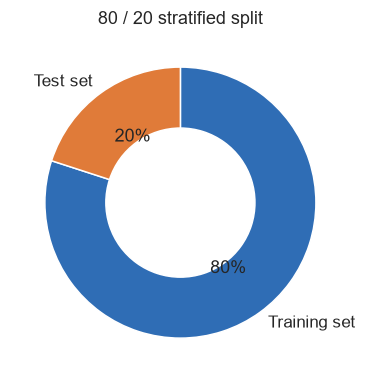

In [10]:
X = df_pre[FEATURES].values
y = df_pre[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Training set: {len(X_train)} samples | Test set: {len(X_test)} samples")
print("Per crop in test set:", np.unique(np.bincount(y_test)))

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=["Training set", "Test set"], autopct="%1.0f%%",
        colors=["#2f6db5", "#e07b39"], wedgeprops=dict(width=0.45), startangle=90, counterclock=False)
plt.title("80 / 20 stratified split"); plt.show()

## 2.2 Four classifiers trained
| Model | Setup | Idea |
|---|---|---|
| Decision Tree | Gini criterion, full depth | Tree of if-then threshold rules — simple and easy to interpret |
| Random Forest | 100 trees | Many trees on random subsets, majority vote — robust, low variance |
| K-Nearest Neighbours | k = 5 | Most common crop among the closest training samples — needs scaled data |
| Support Vector Machine | RBF kernel | Widest-margin boundary between crops — strong on well-separated classes |

In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM":           SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN":           KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name:14s} trained")

Random Forest  trained


SVM            trained
KNN            trained
Decision Tree  trained


## 2.3 Model comparison on the test set (440 unseen samples)

Random Forest  99.55%   438.0 of 440 correct
SVM            99.32%   437.0 of 440 correct
KNN            98.18%   432.0 of 440 correct
Decision Tree  97.95%   431.0 of 440 correct


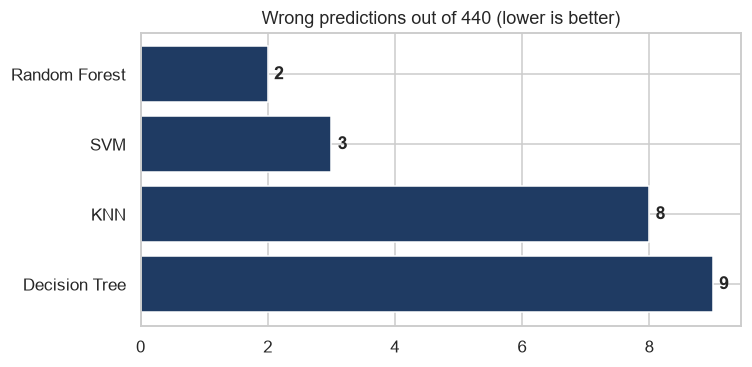

In [12]:
comparison = pd.DataFrame({
    "Test accuracy": {n: accuracy_score(y_test, p) for n, p in predictions.items()},
    "Correct":       {n: int((p == y_test).sum()) for n, p in predictions.items()},
    "Wrong":         {n: int((p != y_test).sum()) for n, p in predictions.items()},
}).sort_values("Test accuracy", ascending=False)

for n, r in comparison.iterrows():
    print(f"{n:14s} {r['Test accuracy']:.2%}   {r['Correct']} of {len(y_test)} correct")

plt.figure(figsize=(7, 3.5))
wrong = comparison["Wrong"].sort_values(ascending=False)
plt.barh(wrong.index, wrong.values, color="#1f3b63")
for i, v in enumerate(wrong.values):
    plt.text(v + 0.1, i, str(v), va="center", fontweight="bold")
plt.title(f"Wrong predictions out of {len(y_test)} (lower is better)")
plt.tight_layout(); plt.show()

## 2.4 Best model selection

Best model: Random Forest  —  99.55% test accuracy, 2 errors in 440


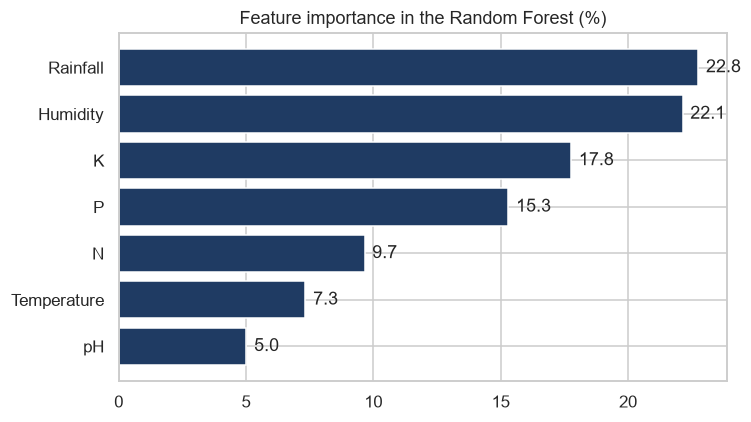

Top two features together drive 45% of the decision.


In [13]:
best_name = comparison.index[0]
best_model = models[best_name]
print(f"Best model: {best_name}  —  {comparison.loc[best_name, 'Test accuracy']:.2%} test accuracy, "
      f"{comparison.loc[best_name, 'Wrong']} errors in {len(y_test)}")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_ * 100,
                    index=["N", "P", "K", "Temperature", "Humidity", "pH", "Rainfall"]).sort_values()
    plt.figure(figsize=(7, 4))
    plt.barh(imp.index, imp.values, color="#1f3b63")
    for i, v in enumerate(imp.values):
        plt.text(v + 0.3, i, f"{v:.1f}", va="center")
    plt.title(f"Feature importance in the {best_name} (%)")
    plt.tight_layout(); plt.show()
    print(f"Top two features together drive {imp.iloc[-2:].sum():.0f}% of the decision.")

## 2.5 Save for deployment
The best model is stored together with the **scaler** and the **label encoder** (plus the IQR capping bounds, so the app treats inputs the same way as the training data).

In [14]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(CAP_BOUNDS, "cap_bounds.pkl")
print("Saved: best_model.pkl, scaler.pkl, label_encoder.pkl, cap_bounds.pkl")

Saved: best_model.pkl, scaler.pkl, label_encoder.pkl, cap_bounds.pkl


## 2.6 Prototype logic (same as the Streamlit app)
User enters 7 values → same preprocessing as training → model predicts probabilities → **recommended crop, confidence, top 3 crops, probability chart**

Recommended Crop: Papaya   |   Confidence: 25.00%
Top crop recommendations:
   Papaya        25.00%
   Mango         22.00%
   Pigeonpeas    11.00%


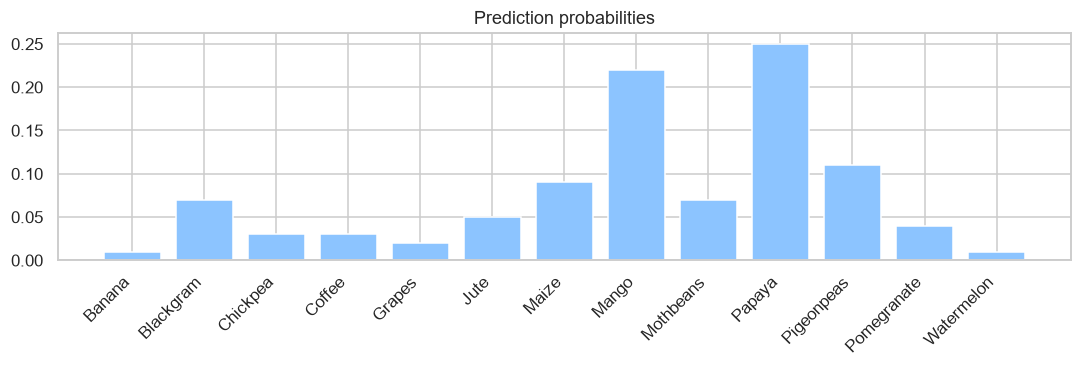

In [15]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall, model=best_model, top_k=3):
    raw = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=FEATURES)
    for f in FEATURES:                                   # same IQR capping as training
        raw[f] = raw[f].clip(*CAP_BOUNDS[f])
    x = scaler.transform(raw)                            # same scaling as training
    proba = model.predict_proba(x)[0]
    order = np.argsort(proba)[::-1]
    crops = label_encoder.inverse_transform(order)
    return {
        "recommended": crops[0],
        "confidence": proba[order[0]] * 100,
        "top": [(c, proba[i] * 100) for c, i in zip(crops[:top_k], order[:top_k])],
        "all_proba": pd.Series(proba, index=label_encoder.classes_),
    }

# Demo with the default values from the input screen
out = recommend_crop(N=47, P=50, K=50, temperature=25, humidity=70, ph=6.5, rainfall=100)
print(f"Recommended Crop: {out['recommended'].capitalize()}   |   Confidence: {out['confidence']:.2f}%")
print("Top crop recommendations:")
for c, p in out["top"]:
    print(f"   {c.capitalize():12s} {p:6.2f}%")

nz = out["all_proba"][out["all_proba"] > 0.001]
plt.figure(figsize=(10, 3.5))
plt.bar(nz.index.str.capitalize(), nz.values, color="#8cc4ff")
plt.title("Prediction probabilities"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

---
# Section 03 — Model Evaluation & Prototype Testing *(Group 3)*
## 3.1 Evaluation metrics for all models
| Metric | Formula | Meaning |
|---|---|---|
| Accuracy | correct ÷ all | Overall share of right answers |
| Precision | TP ÷ (TP + FP) | When the model says "rice", how often is it right? |
| Recall | TP ÷ (TP + FN) | Of all real rice samples, how many were found? |
| F1-score | 2·P·R ÷ (P + R) | Balance of precision and recall |

Precision, recall and F1 are **macro-averaged** over the 22 crops.

In [16]:
rows = []
for name, model in models.items():
    p = predictions[name]
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p, average="macro"),
        "Recall":    recall_score(y_test, p, average="macro"),
        "F1-score":  f1_score(y_test, p, average="macro"),
        "Train accuracy": accuracy_score(y_train, model.predict(X_train)),
        f"Errors / {len(y_test)}": int((p != y_test).sum()),
    })
metrics = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
metrics["Model"] = np.where(metrics.index == 0, "★ " + metrics["Model"], metrics["Model"])
metrics.style.format({c: "{:.2%}" for c in ["Accuracy", "Precision", "Recall", "F1-score", "Train accuracy"]}).hide(axis="index")

Model,Accuracy,Precision,Recall,F1-score,Train accuracy,Errors / 440
★ Random Forest,99.55%,99.57%,99.55%,99.55%,100.00%,2
SVM,99.32%,99.35%,99.32%,99.32%,98.64%,3
KNN,98.18%,98.24%,98.18%,98.16%,98.64%,8
Decision Tree,97.95%,98.06%,97.95%,97.94%,100.00%,9


In [17]:
gap = {r["Model"]: r["Train accuracy"] - r["Accuracy"] for _, r in metrics.iterrows()}
worst = max(gap, key=gap.get)
print(f"Largest train–test gap: {worst} ({gap[worst]*100:.2f} pp) → overfits the most")
print("\nPer-crop report for the best model:\n")
print(classification_report(y_test, predictions[best_name], target_names=label_encoder.classes_, digits=4))

Largest train–test gap: Decision Tree (2.05 pp) → overfits the most

Per-crop report for the best model:

              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        20
      banana     1.0000    1.0000    1.0000        20
   blackgram     1.0000    0.9500    0.9744        20
    chickpea     1.0000    1.0000    1.0000        20
     coconut     1.0000    1.0000    1.0000        20
      coffee     1.0000    1.0000    1.0000        20
      cotton     1.0000    1.0000    1.0000        20
      grapes     1.0000    1.0000    1.0000        20
        jute     0.9524    1.0000    0.9756        20
 kidneybeans     1.0000    1.0000    1.0000        20
      lentil     1.0000    1.0000    1.0000        20
       maize     0.9524    1.0000    0.9756        20
       mango     1.0000    1.0000    1.0000        20
   mothbeans     1.0000    1.0000    1.0000        20
    mungbean     1.0000    1.0000    1.0000        20
   muskmelon     1.0000    1.

## 3.2 Does it generalise? 5-fold cross-validation (2,200 samples)

Random Forest  99.59% ± 0.33%


SVM            98.59% ± 0.39%
KNN            97.77% ± 0.65%


Decision Tree  98.77% ± 0.68%


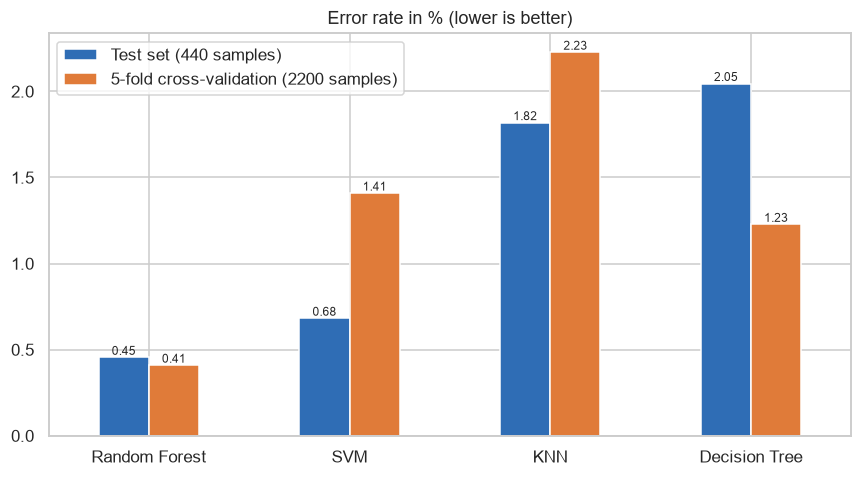

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    cv_rows.append({"Model": name, "CV mean": scores.mean(), "CV std": scores.std(),
                    "Test error %": (1 - accuracy_score(y_test, predictions[name])) * 100,
                    "CV error %": (1 - scores.mean()) * 100})
    print(f"{name:14s} {scores.mean():.2%} ± {scores.std():.2%}")
cv_df = pd.DataFrame(cv_rows).set_index("Model").loc[comparison.index]

ax = cv_df[["Test error %", "CV error %"]].plot(kind="bar", figsize=(8, 4.5), color=["#2f6db5", "#e07b39"], rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8)
ax.set_title("Error rate in % (lower is better)"); ax.set_ylabel("")
ax.legend([f"Test set ({len(y_test)} samples)", f"5-fold cross-validation ({len(y)} samples)"])
plt.tight_layout(); plt.show()

## 3.3 Error analysis — confusion matrix of the best model

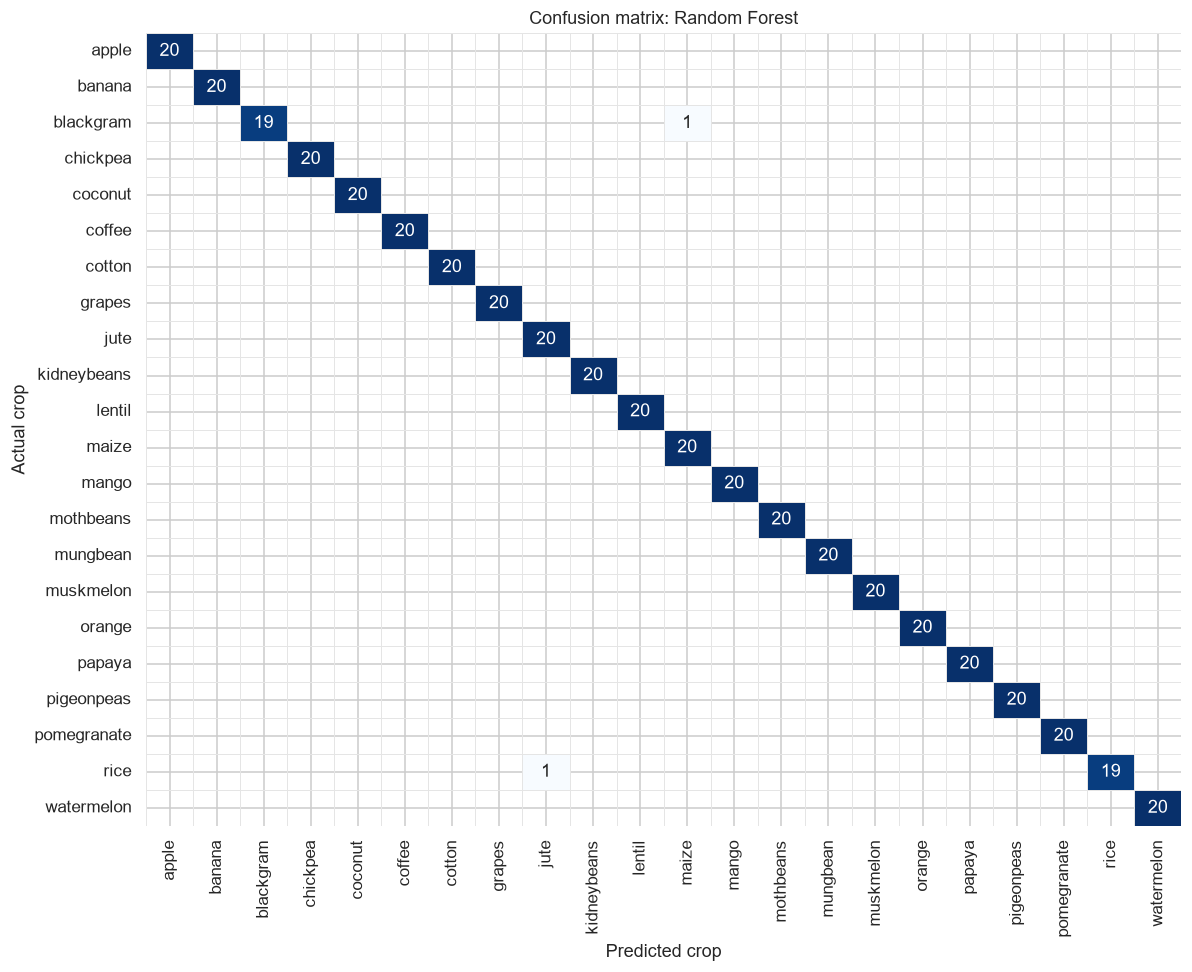

438 / 440 test samples predicted correctly
18 of 22 crops have perfect precision and recall

Errors:
   Blackgram    → predicted Maize  (1)
   Rice         → predicted Jute  (1)


In [19]:
cm = confusion_matrix(y_test, predictions[best_name])
plt.figure(figsize=(11, 9))
mask_zero = cm == 0
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, mask=mask_zero, linewidths=0.5, linecolor="#e5e5e5",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion matrix: {best_name}"); plt.xlabel("Predicted crop"); plt.ylabel("Actual crop")
plt.tight_layout(); plt.show()

correct = np.trace(cm)
per_class_ok = int(((cm.diagonal() == cm.sum(axis=1)) & (cm.diagonal() == cm.sum(axis=0))).sum())
print(f"{correct} / {len(y_test)} test samples predicted correctly")
print(f"{per_class_ok} of {len(label_encoder.classes_)} crops have perfect precision and recall")
print("\nErrors:")
for i, j in zip(*np.where((cm > 0) & ~np.eye(len(cm), dtype=bool))):
    print(f"   {label_encoder.classes_[i].capitalize():12s} → predicted {label_encoder.classes_[j].capitalize()}  ({cm[i, j]})")

## 3.4 Which crops get confused? (all 4 models combined)

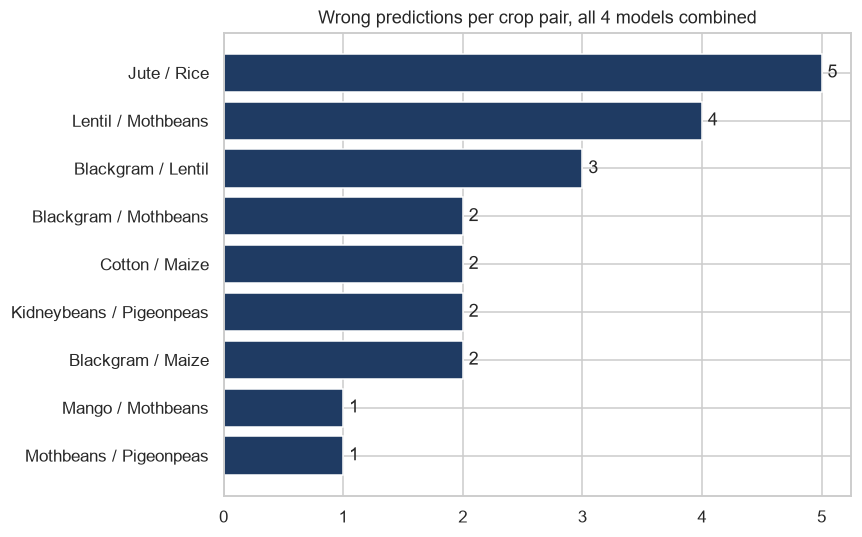

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
jute,78.4,46.9,40.0,25.0,79.6,6.7,174.8
rice,79.9,47.6,39.9,23.7,82.3,6.4,236.2


In [20]:
pair_counts = {}
for name, p in predictions.items():
    for a, b in zip(y_test, p):
        if a != b:
            key = " / ".join(c.capitalize() for c in sorted(label_encoder.inverse_transform([a, b])))
            pair_counts[key] = pair_counts.get(key, 0) + 1
pair_counts = pd.Series(pair_counts, dtype=int).sort_values()

plt.figure(figsize=(8, 0.45 * len(pair_counts) + 1))
plt.barh(pair_counts.index, pair_counts.values, color="#1f3b63")
for i, v in enumerate(pair_counts.values):
    plt.text(v + 0.05, i, str(v), va="center")
plt.title("Wrong predictions per crop pair, all 4 models combined")
plt.tight_layout(); plt.show()

# average soil/climate profile of the most-confused pair
if len(pair_counts):
    top_pair = pair_counts.index[-1].lower().split(" / ")
    display(df[df[TARGET].isin(top_pair)].groupby(TARGET)[FEATURES].mean().round(1))

## 3.5 Prototype testing — unseen samples
Raw field values from the unseen test set, passed through the same preprocessing and the saved model:

In [21]:
samples = pd.DataFrame([
    [140, 38,  15, 24.1, 75.9, 6.0,  69.9, "cotton"],
    [71,  54,  16, 22.6, 63.7, 5.7,  87.8, "maize"],
    [25,  68,  77, 20.1, 15.1, 7.7,  85.7, "chickpea"],
    [60,  49,  44, 20.8, 84.5, 6.2, 240.1, "rice"],
    [0,  133, 200, 23.7, 90.5, 5.7, 104.2, "apple"],
    [109, 31,  27, 23.1, 50.4, 7.0, 164.5, "coffee"],
], columns=FEATURES + ["Actual"])

res = [recommend_crop(*r[FEATURES]) for _, r in samples.iterrows()]
samples["Predicted"]  = [("✓ " if o["recommended"] == a else "✗ ") + o["recommended"].capitalize()
                         for o, a in zip(res, samples["Actual"])]
samples["Confidence"] = [f"{o['confidence']:.0f}%" for o in res]
samples["Actual"] = samples["Actual"].str.capitalize()
passed = sum(s.startswith("✓") for s in samples["Predicted"])
print(f"{passed} / {len(samples)} sample checks passed  •  min confidence {min(o['confidence'] for o in res):.0f}%")
samples

6 / 6 sample checks passed  •  min confidence 99%


,N,P,K,temperature,humidity,ph,rainfall,Actual,Predicted,Confidence
0,140,38,15,24.1,75.9,6.0,69.9,Cotton,✓ Cotton,100%
1,71,54,16,22.6,63.7,5.7,87.8,Maize,✓ Maize,99%
2,25,68,77,20.1,15.1,7.7,85.7,Chickpea,✓ Chickpea,100%
3,60,49,44,20.8,84.5,6.2,240.1,Rice,✓ Rice,99%
4,0,133,200,23.7,90.5,5.7,104.2,Apple,✓ Apple,100%
5,109,31,27,23.1,50.4,7.0,164.5,Coffee,✓ Coffee,99%


## 3.6 Prototype test scenarios
The same input checks the Streamlit form enforces, written as a function so they can be tested here.

In [22]:
TRAIN_MIN, TRAIN_MAX = df[FEATURES].min(), df[FEATURES].max()

def validate_inputs(values):
    # returns (ok, message). values = dict of the 7 fields (may contain None / text)
    for f in FEATURES:
        v = values.get(f)
        if v is None or v == "":
            return False, f"'{f}' is empty"
        try:
            v = float(v)
        except (TypeError, ValueError):
            return False, f"'{f}' must be a number"
        if v < 0:
            return False, f"'{f}' cannot be negative"
        if f == "humidity" and v > 100:
            return False, "humidity cannot exceed 100%"
        if f == "ph" and not (0 <= v <= 14):
            return False, "pH must be between 0 and 14"
    return True, "ok"

base = dict(N=90, P=42, K=43, temperature=20.9, humidity=82.0, ph=6.5, rainfall=202.9)
scenarios = [
    ("Functional", "Valid input",       base),
    ("Functional", "Known sample",      dict(N=60, P=49, K=44, temperature=20.8, humidity=84.5, ph=6.2, rainfall=240.1)),
    ("Boundary",   "Minimum / maximum", dict(base, ph=3.5, rainfall=298.6, N=0)),
    ("Validation", "Empty field",       dict(base, K=None)),
    ("Validation", "Wrong type",        dict(base, P="abc")),
    ("Validation", "Out of range",      dict(base, N=-5, humidity=120)),
]
rows = []
for i, (typ, name, vals) in enumerate(scenarios, 1):
    ok, msg = validate_inputs(vals)
    result = recommend_crop(**{k: float(v) for k, v in vals.items()})["recommended"].capitalize() if ok else "—"
    rows.append({"#": i, "Type": typ, "Scenario": name, "Accepted": "Yes" if ok else "No",
                 "Message": msg, "Prediction": result})
pd.DataFrame(rows).set_index("#")

,Type,Scenario,Accepted,Message,Prediction
#,,,,,
1,Functional,Valid input,Yes,ok,Rice
2,Functional,Known sample,Yes,ok,Rice
3,Boundary,Minimum / maximum,Yes,ok,Rice
4,Validation,Empty field,No,'K' is empty,—
5,Validation,Wrong type,No,'P' must be a number,—
6,Validation,Out of range,No,'N' cannot be negative,—


## Download outputs (Colab)

In [23]:
outputs = ["crop_recommendation_preprocessed.csv", "best_model.pkl", "scaler.pkl", "label_encoder.pkl", "cap_bounds.pkl"]
try:
    from google.colab import files
    for f in outputs:
        files.download(f)
except ImportError:
    print("Not running on Colab — files are saved in the current folder:", outputs)

Not running on Colab — files are saved in the current folder: ['crop_recommendation_preprocessed.csv', 'best_model.pkl', 'scaler.pkl', 'label_encoder.pkl', 'cap_bounds.pkl']
